# Big Data(Büyük Veri)

Çok çok daha büyük miktarlarda veriyi, bazı kısıtları ortadan kaldırarak işlemeye denir. 

Geleneksel yöntemlerle işlenemeyen büyüklükteki verilere Büyük Veri denir.

Büyük veri bir problemdir. Çünkü geleneksel yöntemlerle işlenememektedir, kendine has işlenme yöntemleri bulunmaktadır.

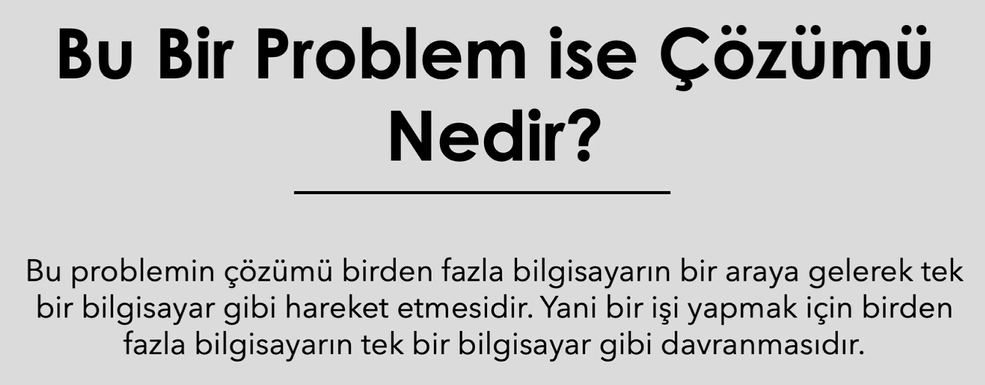

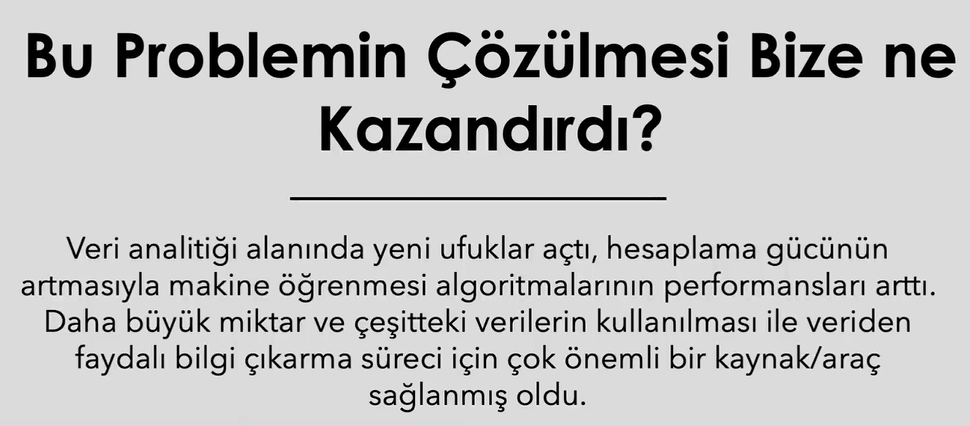

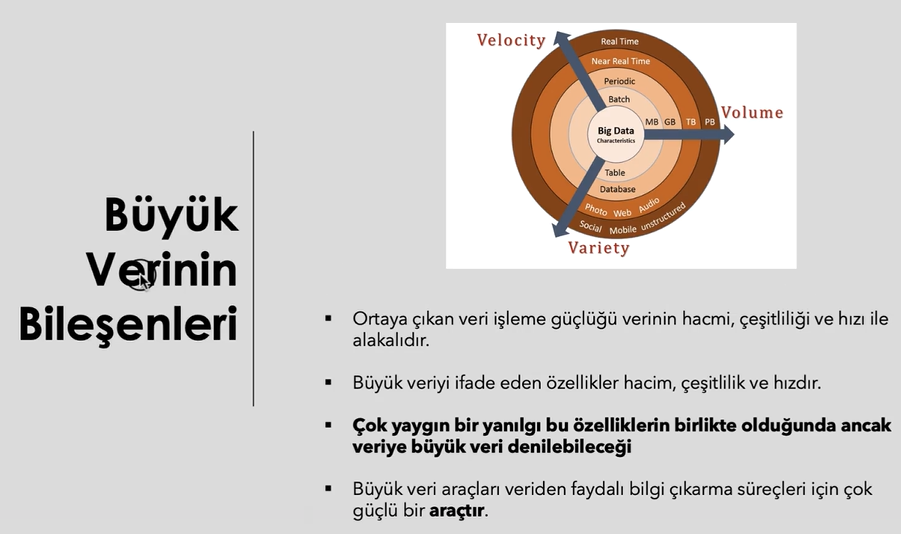

Yani bir veriye büyük veri diyebilmemiz için hem büyük hacimde olması, hem hızlı olması hem de çeşitli verilerden oluşması gerekmiyor. Bunlardan birini barındırsa yeterli büyük veri diyebilmemiz için. "İlişkisel veritabanlarında tutamadığın, geleneksel veri işleme yöntemleriyle işleyemediğin veriye big data de zaten" diyor hocamız.

# Apache Hadoop

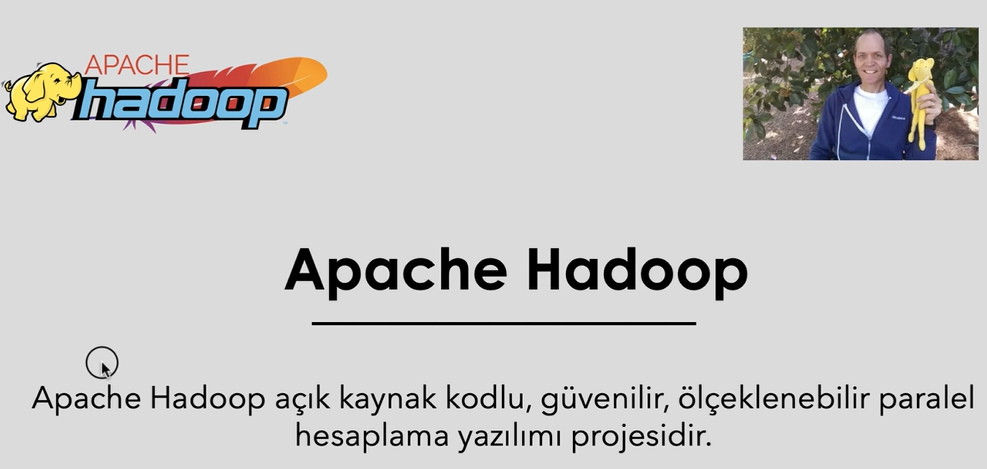

Big data araçlarında ilk akla gelen ve bütün büyük veri dünyasının temelini oluşturan bir framework'tür

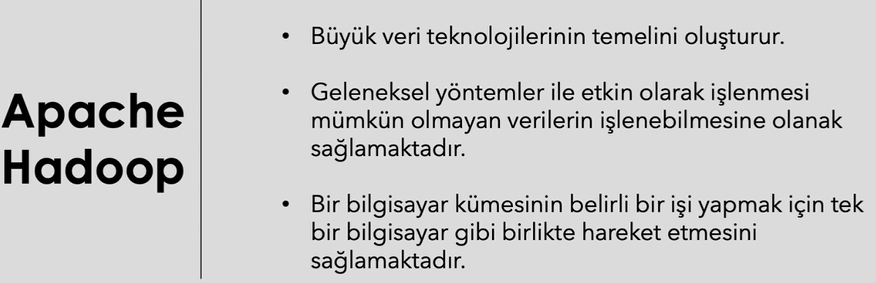

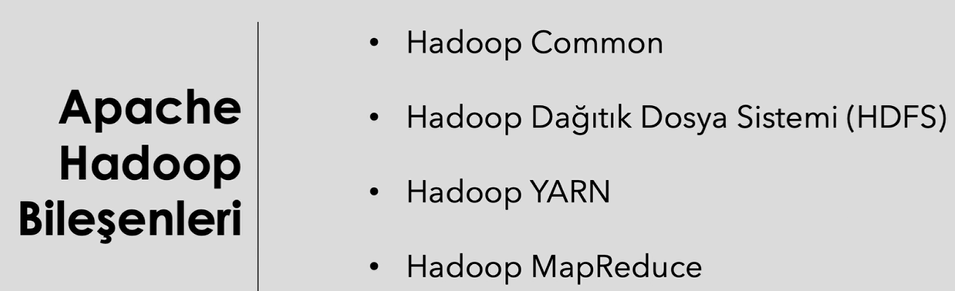

* Haadop Common: Diğer tüm modülleri destekleyen ortak gereksinimlerdir.
* HDFS - Haadop Distributed File System: yerel dosya sistemleri olan ntfs ve fat32 dosya sistemleri gibi bir dosya sistemidir. Bunlardan farkı, büyük veriyi depolamak ve kontrol etmeyi sağlamasıdır.
*  Haadop YARN: Kaynak yönetimi ve iş planlaması için kullanılır. Kullanılacak olan 1'den fazla makinanın iş dağıtımı ve yönetimi konularla ilgilenir. 
*  Haadop MapReduce (Yazılımsal anlamda en önemlisi): Aynı ağdaki dağıtık bilgisayar kümeleri üzerinde büyük veri analizi, büyük veri işleme işlemleri için geliştirilmiş bir programlama modelidir.

Birden fazla bilgisayarın bir bilgisayar gibi hareket etmesi:

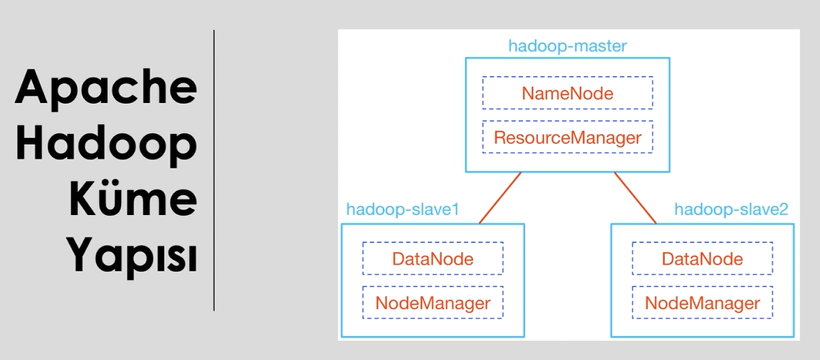

Master, yapılacak olan işleri slave'lere dağıtır. Senin işin bu, senin işin bu gibisinden.

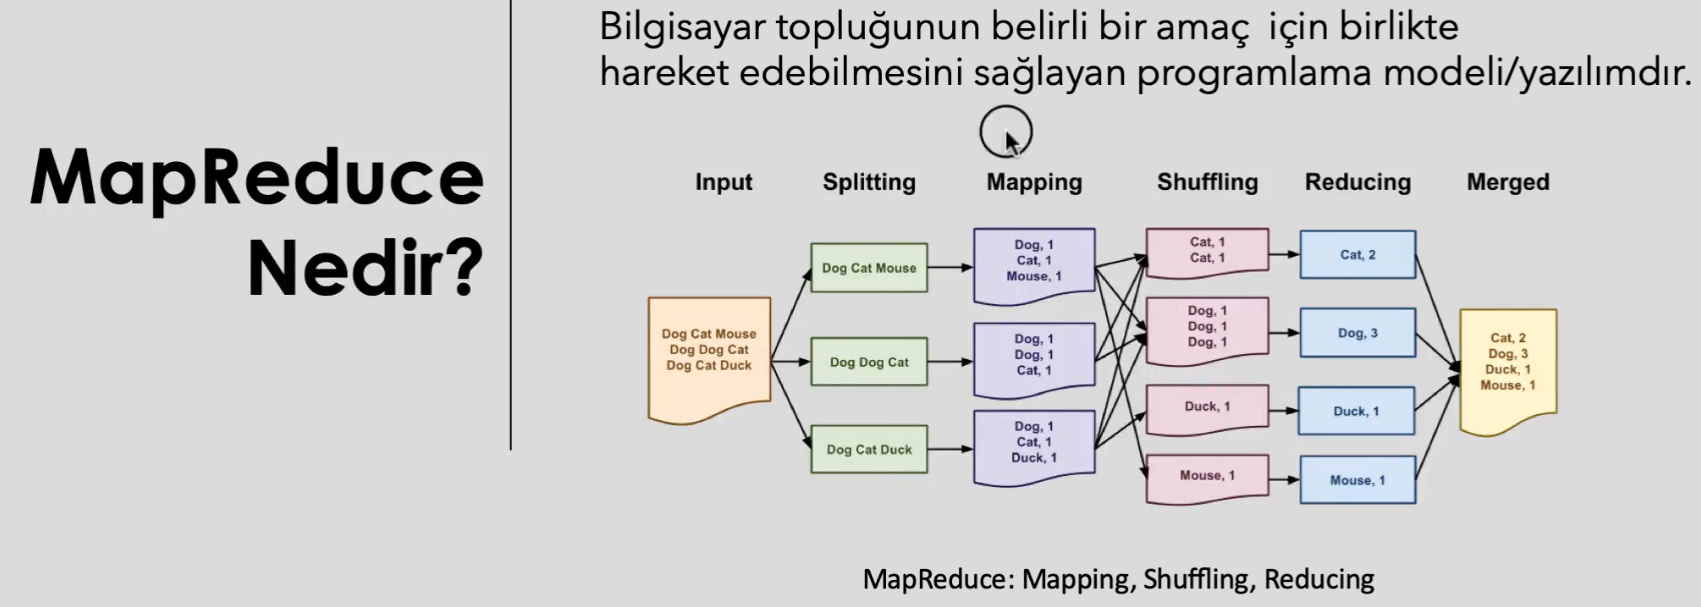

Daha iyi anlamak için bir kuruyemişçi metaforu üzerinden devam edelim:
Önceden bir kuruyemşçiye 1 ton karışık kuruyemiş geldiğinde, kuruyemişçi bu 1 tonun başına oturup fındıkları ayrı bir yere, kajuları, çekirdekleri, bademleri hepsini kendi başına ayırıyordu ancak şimdi yeni teknolojide MapReduce sayesinde kuruyemişçi 10 tane eleman çağırıyor ve her birini sadece 1 kuruyemiş çeşidinden sorumlu hale getirip herkesin daha verimli ve hızlı iş yapmasını sağlıyor. Yani elemanlardan birisi o 1 ton içerisinde sadece kajuları arıyor, diğerleri bademleri vs.

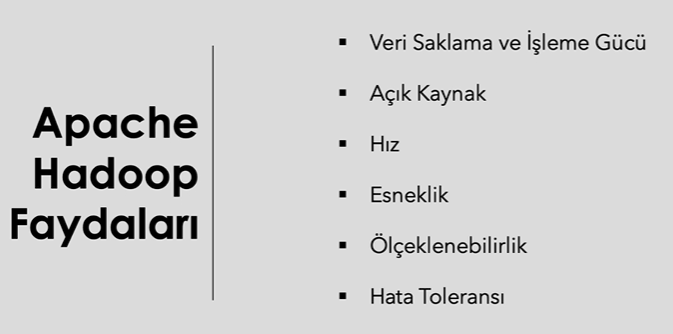

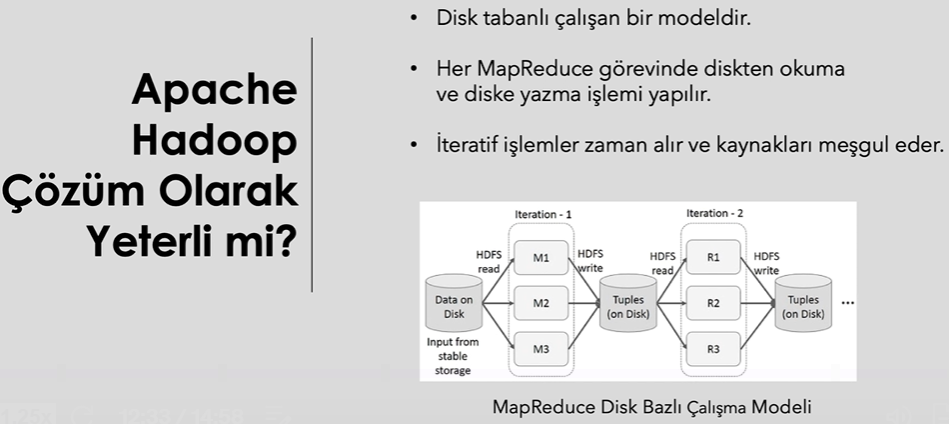

Burada yapılan bu diske yazma ve diskten okuma mevzusu apache haadop'u performanssız hale getiriyor. Bu diske yazma ve diskten okuma kısmını ram'e yazma ve ram'den okuma olarak düzeltilmiş versiyonuna apache spark diyoruz bugün. 

# Apache Spark

Küme üzerinde **hızlı** ve genel amaçlı bilgi işleme sistemidir. 

Apache Haadop'un alternatifi değildir, apache haadop'un üzerin kurulmuş olan, map reduce işleminin disk bazlı yönetimini rame taşıyarak daha performanslı hale getiren Apache Haadop'tur aslında.

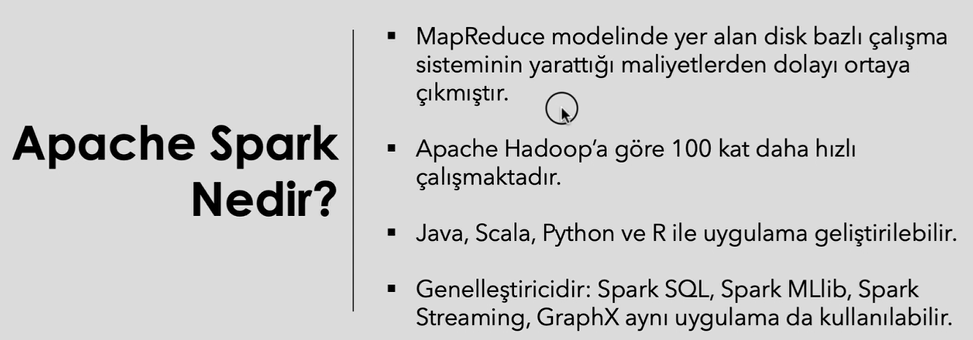

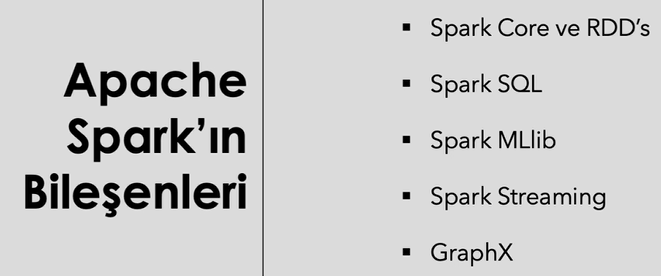

* **Spark Core ve RDD's**: Haadop Common'a benzer olarak, hafıza yönetimi, görevlerin dağıtılması, hata kurtarma, saklama, dosya işlemleri vb işlemleri gibi temel bileşenleri yapar. Apache Spark'ın programlama modelinden bahsettik, verinin bellek içi tutularak paralel işlenmesini ifade eden RDD's dir. Dayanıklı dağıtık datasetler dir açılımı.

RDD's:

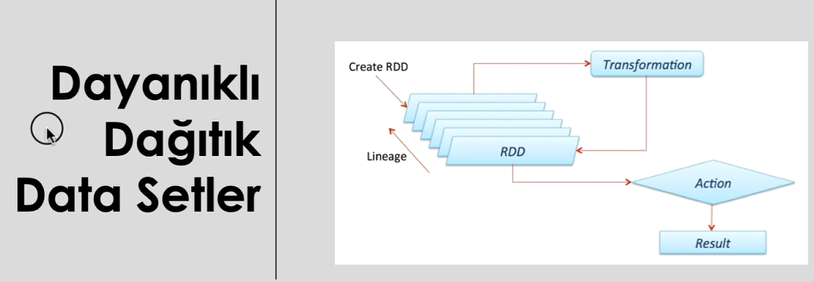

RDD's'in çalışması 3 ana bileşenden oluşur:
1) RDD: Yapılacak işleme göre RDD's üretilir ve bekletilir, bu esnada diske yazma işlemi gerçekleşmez. Bunu in memory, yani ram üzerinde gerçekleştirir. 
2) Transformation: burada RDD's üzerinden yeni RDD'sler üretilebilir. Örneğin veriyi filtrelemiş olabiliriz, bu da bir işlemden sonra tekrar RDD'sin tetiklenmesi gerektiği anlamına gelir, bunu da Transformation yapar. Transofrmation sonucu üretilen RDD'sler işlenir ve toplanarak sonuçlar elde edilir. Bu sonuçlar elde edilmesine rağmen aksiyon işlemi tetiklenmeden execution işlemi gerçekleştirilmez
3) Action: Burası aksiyon adımıdır, en son adımdır ve buradan sonra execution olur ve diske yazılır.

RDD's, yapısı gereği **in memory**(rame yazar) ve **lazy evoluation**(tüm işlemlerden sonra execution ve diske yazma yaptığı için) olarak adlandırılır. 

Örneğin ailemizle yemekteyiz, anne bize oğlum kalk kaşık unutmuşum, kaşık al gel dedi, biz gideriz mutfağa ve alır geliriz, sonra anne yine tuzluğu unuttum git getir der, biz de gider getiririz, sonra oğlum bardak unutmuşum der ve biz de gider getiririz. İşte bu işlem hadoop'u kızdıran işlemdir. RDD ise, anne bir şey istediğinde mutfağa gider ve gelmez, bekler, sonrasında annenin diğer istekleri de orada olduğu için karşılanır ve tüm istekler bittiğinden emin olunduğunda hepsini birlikte getirir ve kalk otur yapmamış olur. Sparkın Haadop gibi her adımda diske yazmama işlemini metaforla anlatmış olduk.

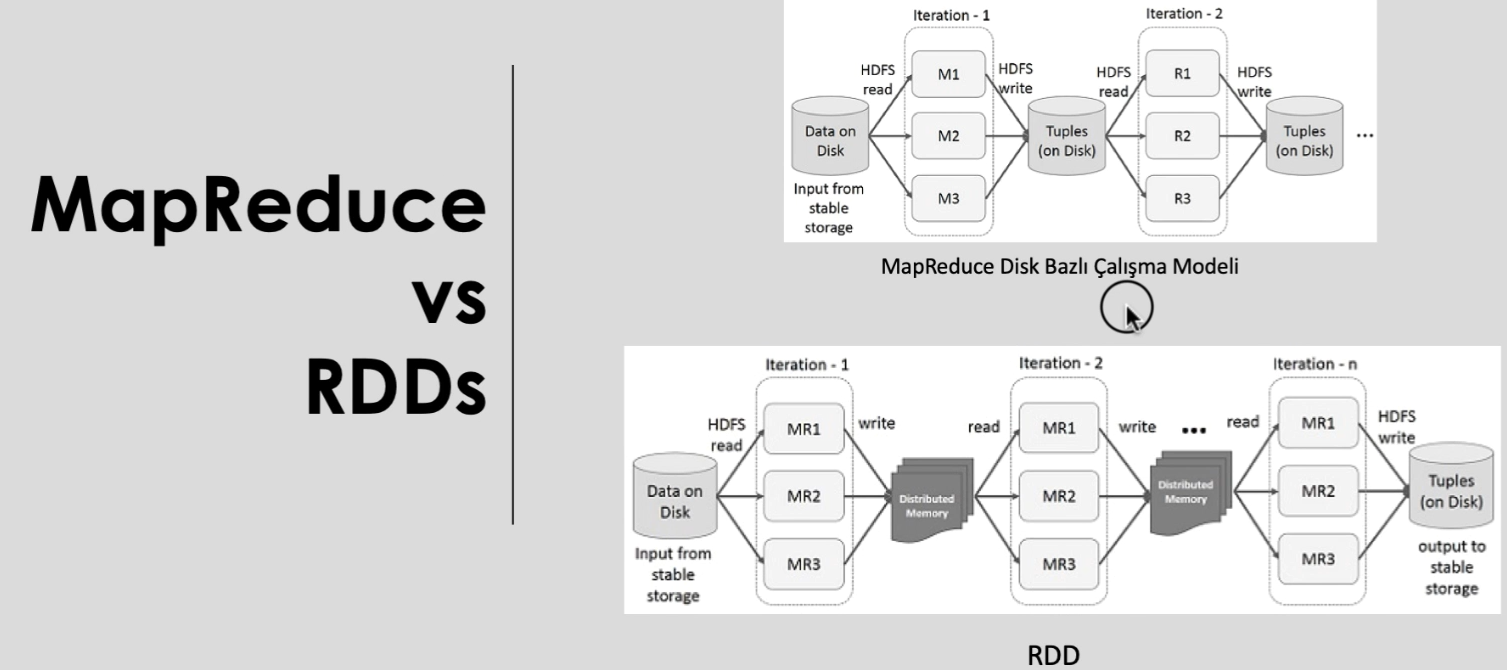

Buradan da anlayabileceğimiz üzere, RDD's, Haadop gibi her işlemde diske yazmak yerine ara işlemleri ramde yapıp en sonda tamamen bittğinden emin olduğu işlemi diske yazar, aralarda ram kullanır.

# Ekosistemin diğer üyeleri

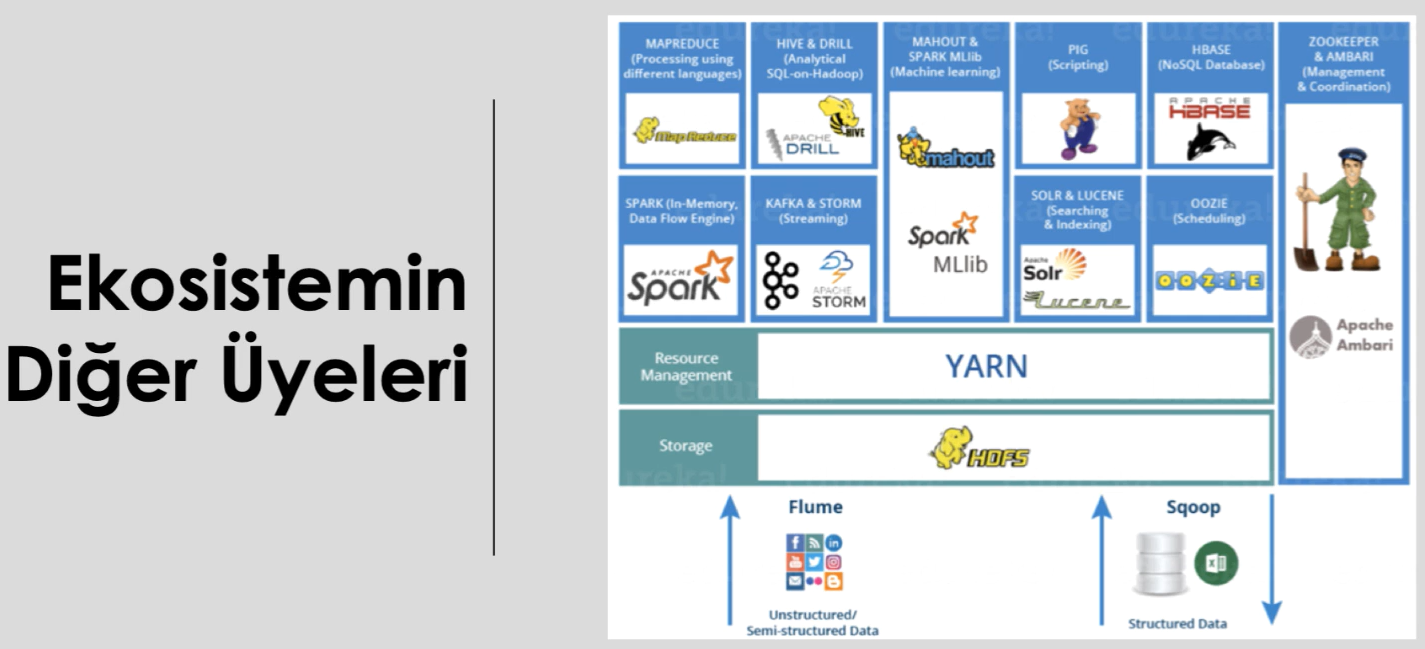

* Yapısal olmayan veriler, sosyal medya ve diğer mecralardan Flume aracılığıyla, yapısal veriler ise Sqoop aracılığıyla HDFS'e aktarılır ya da oradan geri alınır.
* YARN ile kaynak yönetimi yapılır.
* ZOOKEEPER & AMBARI: Haadop servislerini kurmak ve yönetmek için kullanılır.
* OOZIE: Job Scheduling işlemleri için kullanılır. Örneğin sabah 3'te ETL sürecini başlat, sabah 5'te MYSQL tablolarına şunu bas gibi.
* HBASE: NoSQL Database. Sütun bazlı veri tutma veritabanı. Büyük boyutlu verileri realtime read ve write yapabileceğimiz nosql alan.
* PIG: Bir Scripting dili. MSQL tarzı işlemler yapmak için kullanabileceğimiz ama daha çok arkatarafla ilgili çalışma sağlayabileceğimiz bir yer.
* MAHOUT/Spark MLib: Hadoop'un makina öğrenmesi aracı. 
* Apache Hive: Arkaplanda SQL komutlarını MapReduce'e çevirerek, büyük veri üzerinde SQL sorguları yapabilmeyi sağlayan bir program.
* KAFKA & STORM: Akan veri için kullanılır.
* Spark: in memory dataflow engine

Biz Apache Spark kullanabilmek için PySpark kullanacağız.

# Konfigurasyon ve Spark Bağlantısı 

In [2]:
#!pip install pyspark

In [4]:
from pyspark import SparkContext
sc = SparkContext(master="local")
sc # Spark UI yazan kısma dokunduğumuzda swagger UI gibi bir şey açılıyor. oradan yapmış olduğumuz işleri vs görebiliyormuşuz

<SparkContext master=local appName=pyspark-shell>

In [5]:
sc.stop() # yukarıda açtığımız session'u böyle kapatmalıyız. nasılk fastapide açılan portu ctrl+c yaparak kapatıyorduysak burada da bu

In [6]:
# şimdi daha gelişmiş şekilde pyspark session'ı açacağız:
import pyspark
from pyspark.sql import SparkSession
from pyspark.conf import SparkConf
from pyspark import SparkContext

spark = SparkSession.builder.master("local").appName("PySpark_Uygulamasi").getOrCreate()

sc = spark.sparkContext
sc

<SparkContext master=local appName=PySpark_Uygulamasi>

In [7]:
sc.stop()

# Spark ile Temel DataFrame İşlemleri

Pandas dataframe'indeki tüm özellikler spark dataframe'inde yok. bazı fonksiyonlar sparkda farklı veya yok. burada buna bir bakış atacağız

In [11]:
# şimdi daha gelişmiş şekilde pyspark session'ı açacağız:
import pyspark
from pyspark.sql import SparkSession
from pyspark.conf import SparkConf
from pyspark import SparkContext

spark = SparkSession.builder.master("local").appName("PySpark_Uygulamasi").getOrCreate()

sc = spark.sparkContext
sc

<SparkContext master=local appName=PySpark_Uygulamasi>

In [12]:
spark_df = spark.read.csv("diabetes.csv", header=True, inferSchema=True)

In [13]:
spark_df.printSchema()

root
 |-- Pregnancies: integer (nullable = true)
 |-- Glucose: integer (nullable = true)
 |-- BloodPressure: integer (nullable = true)
 |-- SkinThickness: integer (nullable = true)
 |-- Insulin: integer (nullable = true)
 |-- BMI: double (nullable = true)
 |-- DiabetesPedigreeFunction: double (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Outcome: integer (nullable = true)



In [14]:
type(spark_df) 

# görülebileceği üzere dataframe değil veritipi, kendisi pyspark dataframe, bu da demek oluyor ki kendine has fonksiyonları var, yani dataframe
# kısmında kullandığımız fonksiyonların hepsini kullanamayız. spark dataframe'e aşina olmak gerek

pyspark.sql.classic.dataframe.DataFrame

In [15]:
spark_df.cache() # bunu yapınca veriyi Ram'e taşımız oluyoruz

DataFrame[Pregnancies: int, Glucose: int, BloodPressure: int, SkinThickness: int, Insulin: int, BMI: double, DiabetesPedigreeFunction: double, Age: int, Outcome: int]

## Pandas Dataframe vs Spark Dataframe

In [17]:
import seaborn as sns
pandas_df = sns.load_dataset("diamonds")
pandas_df = pandas_df.select_dtypes(include=["float64", "int64"])

In [18]:
pandas_df.head() # headi pandas dataframe'de yapınca böyle gözüküyor

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [19]:
spark_df.head() # headi spark dataframe'de yapınca böyle gözüküyor

Row(Pregnancies=6, Glucose=148, BloodPressure=72, SkinThickness=35, Insulin=0, BMI=33.6, DiabetesPedigreeFunction=0.627, Age=50, Outcome=1)

In [20]:
pandas_df.dtypes # pandas dataframe'de dataframe içerisindeki veritiplerini .dtypes iel isteyince böyle gözüküyor

carat    float64
depth    float64
table    float64
price      int64
x        float64
y        float64
z        float64
dtype: object

In [21]:
spark_df.dtypes # spark dataframe'de dataframe içerisindeki veritiplerini .dtypes iel isteyince böyle gözüküyor

[('Pregnancies', 'int'),
 ('Glucose', 'int'),
 ('BloodPressure', 'int'),
 ('SkinThickness', 'int'),
 ('Insulin', 'int'),
 ('BMI', 'double'),
 ('DiabetesPedigreeFunction', 'double'),
 ('Age', 'int'),
 ('Outcome', 'int')]

In [22]:
pandas_df.ndim # pandas dataframe'de number of dimension var

2

In [23]:
spark_df.ndim # spark dataframe'de number of dimension yok

PySparkAttributeError: [ATTRIBUTE_NOT_SUPPORTED] Attribute `ndim` is not supported.

In [44]:
spark_df.size # spark dataframe'de size yok

PySparkAttributeError: [ATTRIBUTE_NOT_SUPPORTED] Attribute `size` is not supported.

In [46]:
# Aralarındaki en önemli farklardan biri: Pandas dataframe'i paralel olarak çalışma özelliğine sahip değilken Spark dataframe'i sahiptir.
# Spark dataframe'i farklı nodelarda cluster içerisinde paralel olarak çalışabilir.

# Pandas dataframe'i ile sparkı karşılaştırınca spark daha lazy(tembel)'dir.

# Spark Dataframe'i immutable'dır, pandas ise mutable'dır

# Pandas'ın veri manipülasyonu ile ilgili özellikleri çok çok daha zengindir. Sparkta ise daha kısıtlıdır.

## Spark Dataframe Değişken Seçme(sütun) İşlemleri

In [48]:
spark_df.show(10) # pandas_df.head(10)'un aynı görüntüsünü bu şekilde alabiliriz

+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|          6|    148|           72|           35|      0|33.6|                   0.627| 50|      1|
|          1|     85|           66|           29|      0|26.6|                   0.351| 31|      0|
|          8|    183|           64|            0|      0|23.3|                   0.672| 32|      1|
|          1|     89|           66|           23|     94|28.1|                   0.167| 21|      0|
|          0|    137|           40|           35|    168|43.1|                   2.288| 33|      1|
|          5|    116|           74|            0|      0|25.6|                   0.201| 30|      0|
|          3|     78|           50|           32|     88|31.0|                   0.248| 26|      1|


In [49]:
spark_df.count() # 768 adet satır varmış bu dataframe'imizde.

768

In [50]:
spark_df.columns # sütunların isimleri 

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [51]:
len(spark_df.columns) # sütunların sayısı 

9

In [52]:
spark_df.describe().show() # pandastaki describe işlemi

+-------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------------+------------------+------------------+
|summary|       Pregnancies|          Glucose|     BloodPressure|     SkinThickness|           Insulin|               BMI|DiabetesPedigreeFunction|               Age|           Outcome|
+-------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------------+------------------+------------------+
|  count|               768|              768|               768|               768|               768|               768|                     768|               768|               768|
|   mean|3.8450520833333335|     120.89453125|       69.10546875|20.536458333333332| 79.79947916666667|31.992578124999977|      0.4718763020833327|33.240885416666664|0.3489583333333333|
| stddev|  3.36957806269887|31.97261819513622|19.355807170644777|15.95

In [53]:
spark_df.describe("Glucose","BloodPressure").show() # dfteki seçili sütunlar için

+-------+-----------------+------------------+
|summary|          Glucose|     BloodPressure|
+-------+-----------------+------------------+
|  count|              768|               768|
|   mean|     120.89453125|       69.10546875|
| stddev|31.97261819513622|19.355807170644777|
|    min|                0|                 0|
|    max|              199|               122|
+-------+-----------------+------------------+



In [54]:
spark_df.select("Glucose","BloodPressure").show(5) # bu sütunların ilk 5 satır değerlerini(gözlem birimlerini) getir

+-------+-------------+
|Glucose|BloodPressure|
+-------+-------------+
|    148|           72|
|     85|           66|
|    183|           64|
|     89|           66|
|    137|           40|
+-------+-------------+
only showing top 5 rows


In [55]:
spark_df.select("Glucose").distinct().count() # Glucose sütununu içerisinde birbirinden farklı 136 değer varmış 

136

In [56]:
spark_df.select("Glucose").dropDuplicates().show() # tekrar eden, birbiriyle aynı olan değerleri siler

+-------+
|Glucose|
+-------+
|    148|
|     85|
|    137|
|     65|
|    133|
|     78|
|    155|
|    108|
|    193|
|    115|
|    126|
|    101|
|     81|
|    183|
|     76|
|    159|
|     44|
|    103|
|     91|
|    128|
+-------+
only showing top 20 rows


In [57]:
spark_df.dropna().count() # verisetimiz içerisinde hiç eksik gözlem olmadığı anlamına geliyor

768

## Spark Dataframe Gözlem Seçme(satır) İşlemleri

In [59]:
spark_df.filter(spark_df.Age>40).show(5) # satır seçmede filter fonskiyonu kullanılır. burada age sütununda 40'tan büyük olanları getir dedik

+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|          6|    148|           72|           35|      0|33.6|                   0.627| 50|      1|
|          2|    197|           70|           45|    543|30.5|                   0.158| 53|      1|
|          8|    125|           96|            0|      0| 0.0|                   0.232| 54|      1|
|         10|    139|           80|            0|      0|27.1|                   1.441| 57|      0|
|          1|    189|           60|           23|    846|30.1|                   0.398| 59|      1|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
only showing top 5 rows


In [60]:
spark_df.filter(spark_df.Age>40).count() # age sütununda 40'tan büyük olanların sayısı kaç

194

In [61]:
spark_df.groupby("Outcome").count().show() # groupby burada da var. diyabet hastası olanların ve olmayanların sayısını getirir

+-------+-----+
|Outcome|count|
+-------+-----+
|      1|  268|
|      0|  500|
+-------+-----+



In [62]:
spark_df.groupby("Outcome").agg({"BMI":"mean"}).show() 
# groupby ile aggregation hesaplama fonksiyonunu kullanarak, diyabet hastası olanların BMI ortalaması ve olmayanların BMI ortalamasını öğrendik

+-------+-----------------+
|Outcome|         avg(BMI)|
+-------+-----------------+
|      1|35.14253731343278|
|      0|30.30419999999996|
+-------+-----------------+



In [63]:
spark_df = spark_df.withColumn("yeni_degisken", spark_df.BMI/2) # yeni_degisken isminde bir sütun oluşturduk, buraya BMI/2 olanları koyduk
spark_df.show(5)

+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+-------------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|yeni_degisken|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+-------------+
|          6|    148|           72|           35|      0|33.6|                   0.627| 50|      1|         16.8|
|          1|     85|           66|           29|      0|26.6|                   0.351| 31|      0|         13.3|
|          8|    183|           64|            0|      0|23.3|                   0.672| 32|      1|        11.65|
|          1|     89|           66|           23|     94|28.1|                   0.167| 21|      0|        14.05|
|          0|    137|           40|           35|    168|43.1|                   2.288| 33|      1|        21.55|
+-----------+-------+-------------+-------------+-------+----+------------------------+-

In [64]:
spark_df.withColumnRenamed("SkinThickness","Deri Kalınlığı").show(5) # var olan bir sütun ismini değiştirmek için

+-----------+-------+-------------+--------------+-------+----+------------------------+---+-------+-------------+
|Pregnancies|Glucose|BloodPressure|Deri Kalınlığı|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|yeni_degisken|
+-----------+-------+-------------+--------------+-------+----+------------------------+---+-------+-------------+
|          6|    148|           72|            35|      0|33.6|                   0.627| 50|      1|         16.8|
|          1|     85|           66|            29|      0|26.6|                   0.351| 31|      0|         13.3|
|          8|    183|           64|             0|      0|23.3|                   0.672| 32|      1|        11.65|
|          1|     89|           66|            23|     94|28.1|                   0.167| 21|      0|        14.05|
|          0|    137|           40|            35|    168|43.1|                   2.288| 33|      1|        21.55|
+-----------+-------+-------------+--------------+-------+----+-----------------

In [65]:
spark_df.drop("Deri Kalınlığı").show(3) # bu şekilde sütun silme işlemi yapabiliriz

+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+-------------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|yeni_degisken|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+-------------+
|          6|    148|           72|           35|      0|33.6|                   0.627| 50|      1|         16.8|
|          1|     85|           66|           29|      0|26.6|                   0.351| 31|      0|         13.3|
|          8|    183|           64|            0|      0|23.3|                   0.672| 32|      1|        11.65|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+-------------+
only showing top 3 rows


In [66]:
# Şu anda bildiğimiz üzere cache dedik, yani ram üzerinde kullanıyoruz spark_df'i, yapıyoruz herşeyi.
# eğer localimize çekmek istersek toPandas isimli fonksiyonu kullanacağız

pandas_df = spark_df.groupby("Outcome","BloodPressure").count().toPandas() # şu anda pandas dataframe'i yaptık onu

In [67]:
pandas_df.head(3) 

# şu anda bu df locale çekildi, artık ramde değil.
# sparkta ramde olmasının sebebi, konunun başında da dediğimiz gibi, big data dünyasında verileri çok büyük olduğu için, her işlem sonrası
# locale kaydedip kaydedip yavaşlama ve hafızadan verme yerine tüm işlemlerini ramde yapıyor. örneğin sparkla biz böyle yaparız,
# işlemler bittikten sonra da çıktı olan df'i locale alır ve inceleriz.

,Outcome,BloodPressure,count
0,1,114,1
1,1,0,16
2,0,65,6


## SQL işlemleri

In [69]:
sc

<SparkContext master=local appName=PySpark_Uygulamasi>

In [70]:
spark_df.registerTempTable("table_df")

C:\Users\since\anaconda3\Lib\site-packages\pyspark\sql\classic\dataframe.py:178: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)


In [71]:
spark.sql("show databases").show() # oluşturduğumuz database'deki dbler

+---------+
|namespace|
+---------+
|  default|
+---------+



In [72]:
spark.sql("show tables").show()# oluşturduğumuz database'deki tablelar

+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
|         | table_df|       true|
+---------+---------+-----------+



In [73]:
spark.sql("select Glucose from table_df").show(5)

+-------+
|Glucose|
+-------+
|    148|
|     85|
|    183|
|     89|
|    137|
+-------+
only showing top 5 rows


In [74]:
spark.sql("select Outcome, mean(Glucose) from table_df group by Outcome").show(5)

+-------+------------------+
|Outcome|     mean(Glucose)|
+-------+------------------+
|      1|141.25746268656715|
|      0|            109.98|
+-------+------------------+



# Büyük Veri Görselleştirme

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
sns.barplot(x="Outcome", y=spark_df.Outcome.index, data=spark_df)

# burası hata verdi çünkü spark_df kullandığımız için. burada veriler ramde olduğu için maalesef olmaz. 
# onu toPandas işlemine tabi tuttuktan sonra görselleştirebiliriz

PySparkAttributeError: [ATTRIBUTE_NOT_SUPPORTED] Attribute `get` is not supported.

In [107]:
sdf = spark_df.toPandas()
sdf.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,yeni_degisken
0,6,148,72,35,0,33.6,0.627,50,1,16.80
1,1,85,66,29,0,26.6,0.351,31,0,13.30
2,8,183,64,0,0,23.3,0.672,32,1,11.65


In [109]:
sdf.Outcome.index

RangeIndex(start=0, stop=768, step=1)

In [26]:
# sns.barplot(x="Outcome", y=sdf.Outcome.index, data=sdf)
# görüldüğü üzere aynı satıra pandas dataframe'i verince sorun çözüldü
# biz big data ile çalışırken ilerleyiş şöyle olacak: 1) veri işleme işlemlerini spark tarafında yapacağız 
# bilgisayarı yormamak ve performansı düşürmemek için, veri işleme işlemleri bittikten sonra son dataframe'i locale çekebilmek adına
# pandas dataframe'ine alacağız ve görselleştirmeyi de burada yapacağız

# Uçtan uca büyük veri de makina öğrenmesi projesi

In [88]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.conf import SparkConf
from pyspark import SparkContext

spark = SparkSession.builder.master("local").appName("Churn_Modellemesi").getOrCreate()

sc = spark.sparkContext
sc

<SparkContext master=local appName=Churn_Modellemesi>

## Verisetini Tanıyalım

Verisetimiz, Müşteri Kayıp Analizidir. Müşterilerimiz isim, yaş, toplam harcama, bizimle geçirdikleri yıl, ziyaret ettikleri hizmetlerimizin sayısı, müşterinin kaybedilip kaybedilmediği gibi bilgiler taşır

In [4]:
spark_df = spark.read.csv("churn.csv", header=True, inferSchema=True, sep=",")

In [5]:
spark_df.cache()

DataFrame[_c0: int, Names: string, Age: double, Total_Purchase: double, Account_Manager: int, Years: double, Num_Sites: double, Churn: int]

In [6]:
spark_df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- Names: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- Total_Purchase: double (nullable = true)
 |-- Account_Manager: integer (nullable = true)
 |-- Years: double (nullable = true)
 |-- Num_Sites: double (nullable = true)
 |-- Churn: integer (nullable = true)



In [7]:
spark_df.show(5)  # genel bir bakış

+---+----------------+----+--------------+---------------+-----+---------+-----+
|_c0|           Names| Age|Total_Purchase|Account_Manager|Years|Num_Sites|Churn|
+---+----------------+----+--------------+---------------+-----+---------+-----+
|  0|Cameron Williams|42.0|       11066.8|              0| 7.22|      8.0|    1|
|  1|   Kevin Mueller|41.0|      11916.22|              0|  6.5|     11.0|    1|
|  2|     Eric Lozano|38.0|      12884.75|              0| 6.67|     12.0|    1|
|  3|   Phillip White|42.0|       8010.76|              0| 6.71|     10.0|    1|
|  4|  Cynthia Norton|37.0|       9191.58|              0| 5.56|      9.0|    1|
+---+----------------+----+--------------+---------------+-----+---------+-----+
only showing top 5 rows


In [8]:
spark_df.count() # 900 adet gözlem varmış

900

In [9]:
len(spark_df.columns) # 8 adet sütun varmış

8

In [10]:
spark_df.distinct().count() # tüm satırlar eşsizmiş. tekrar eden, tüm sütunları birlikte aynı olan herhangi bir satır yokmuş

900

In [11]:
spark_df = spark_df.withColumnRenamed("_c0","index") # saçma olan _c0 adlandırmasından kurtulup asıl yaptığı iş olan index ismini verelim
spark_df.show(3)

+-----+----------------+----+--------------+---------------+-----+---------+-----+
|index|           Names| Age|Total_Purchase|Account_Manager|Years|Num_Sites|Churn|
+-----+----------------+----+--------------+---------------+-----+---------+-----+
|    0|Cameron Williams|42.0|       11066.8|              0| 7.22|      8.0|    1|
|    1|   Kevin Mueller|41.0|      11916.22|              0|  6.5|     11.0|    1|
|    2|     Eric Lozano|38.0|      12884.75|              0| 6.67|     12.0|    1|
+-----+----------------+----+--------------+---------------+-----+---------+-----+
only showing top 3 rows


In [12]:
spark_df = spark_df.toDF(*[c.lower() for c in spark_df.columns]) 
spark_df.show(5)
# verisetimizdeki sütunlarımızın adlarını küçük harfe çevirdik. ileride sorun çıkmaması adına herşeyi aynı standarda getirmenin adımlarından biri

+-----+----------------+----+--------------+---------------+-----+---------+-----+
|index|           names| age|total_purchase|account_manager|years|num_sites|churn|
+-----+----------------+----+--------------+---------------+-----+---------+-----+
|    0|Cameron Williams|42.0|       11066.8|              0| 7.22|      8.0|    1|
|    1|   Kevin Mueller|41.0|      11916.22|              0|  6.5|     11.0|    1|
|    2|     Eric Lozano|38.0|      12884.75|              0| 6.67|     12.0|    1|
|    3|   Phillip White|42.0|       8010.76|              0| 6.71|     10.0|    1|
|    4|  Cynthia Norton|37.0|       9191.58|              0| 5.56|      9.0|    1|
+-----+----------------+----+--------------+---------------+-----+---------+-----+
only showing top 5 rows


In [13]:
string = spark_df.filter(spark_df.index == 439).collect()[0]["names"] 
print(string)
print(type(string))
# bu çıktıyı bir girdi olarak almak için. yani dataframe değerini string olarak verdi. işlenebilir bir girdi olarak elde ettik bu sorguyu yani

Jennifer Wood
<class 'str'>


In [14]:
spark_df.select("names").distinct().count() 

# müşterilerimizin hepsi eşsiz mi? hayır değil ama sadece 1 kişi 1'den fazla kez tekrar etmiş, kalan 899'u eşsiz, farklı kişiler

899

In [15]:
spark_df.groupby("names").count().sort("count", ascending=False).show(3)  # kimmiş bu tekrar eden? Jennifer Wood isimli kişiymiş

+----------------+-----+
|           names|count|
+----------------+-----+
|   Jennifer Wood|    2|
|    Patrick Bell|    1|
|Patrick Robinson|    1|
+----------------+-----+
only showing top 3 rows


In [16]:
spark_df.filter(spark_df["names"] == "Jennifer Wood").show() 

# O 2 kere tekrar eden jennifer wood isimli satırların tamamını görelim. yaşlarından anladığımız üzere aynı kişi değiller.
# Yani bu bir çoklama durumu değil. Dolayısıyla noise yok diyebiliriz. 
# Eğer noise olsaydı onu da şu kodla silebilirdik:              spark_df.select("names").dropDuplicates()

+-----+-------------+----+--------------+---------------+-----+---------+-----+
|index|        names| age|total_purchase|account_manager|years|num_sites|churn|
+-----+-------------+----+--------------+---------------+-----+---------+-----+
|   22|Jennifer Wood|35.0|       9381.12|              1| 6.78|     11.0|    1|
|  439|Jennifer Wood|48.0|      11585.16|              0| 4.61|      9.0|    0|
+-----+-------------+----+--------------+---------------+-----+---------+-----+



In [17]:
spark_df.filter(spark_df.index == 439).show()

+-----+-------------+----+--------------+---------------+-----+---------+-----+
|index|        names| age|total_purchase|account_manager|years|num_sites|churn|
+-----+-------------+----+--------------+---------------+-----+---------+-----+
|  439|Jennifer Wood|48.0|      11585.16|              0| 4.61|      9.0|    0|
+-----+-------------+----+--------------+---------------+-----+---------+-----+



## Veri Analizi

In [19]:
spark_df.describe().show()

+-------+------------------+-------------+-----------------+-----------------+------------------+-----------------+------------------+-------------------+
|summary|             index|        names|              age|   total_purchase|   account_manager|            years|         num_sites|              churn|
+-------+------------------+-------------+-----------------+-----------------+------------------+-----------------+------------------+-------------------+
|  count|               900|          900|              900|              900|               900|              900|               900|                900|
|   mean|             449.5|         NULL|41.81666666666667|10062.82403333334|0.4811111111111111| 5.27315555555555| 8.587777777777777|0.16666666666666666|
| stddev|259.95191863111916|         NULL|6.127560416916251|2408.644531858096|0.4999208935073339|1.274449013194616|1.7648355920350969| 0.3728852122772358|
|    min|                 0|   Aaron King|             22.0|          

In [20]:
# yukarıdaki görüntü bok gibi olduğu için aynısını farklı yolla veren şunu yapıcaz

spark_df.select("age", "total_purchase", "account_manager", "years", "num_sites", "churn").toPandas().describe().T

,count,mean,std,min,25%,50%,75%,max
age,900.0,41.816667,6.127560,22.0,38.0000,42.000,46.000,65.00
total_purchase,900.0,10062.824033,2408.644532,100.0,8497.1225,10045.870,11760.105,18026.01
account_manager,900.0,0.481111,0.499921,0.0,0.0000,0.000,1.000,1.00
years,900.0,5.273156,1.274449,1.0,4.4500,5.215,6.110,9.15
num_sites,900.0,8.587778,1.764836,3.0,7.0000,8.000,10.000,14.00
churn,900.0,0.166667,0.372885,0.0,0.0000,0.000,0.000,1.00


In [21]:
spark_df.filter((spark_df.age>46) | (spark_df.age<36)).show() # bunlar ortalamanın standart sapmasından az veya fazla olan kişiler

+-----+-----------------+----+--------------+---------------+-----+---------+-----+
|index|            names| age|total_purchase|account_manager|years|num_sites|churn|
+-----+-----------------+----+--------------+---------------+-----+---------+-----+
|    5| Jessica Williams|48.0|      10356.02|              0| 5.12|      8.0|    1|
|    7|    Zachary Walsh|32.0|       9885.12|              1| 6.92|      9.0|    1|
|   10|     Paula Harris|30.0|      11575.37|              1| 5.22|      8.0|    1|
|   18|   Lindsay Martin|53.0|       5515.09|              0| 6.85|      8.0|    1|
|   21|      Kevin Ramos|56.0|      12217.95|              1| 5.79|     11.0|    1|
|   22|    Jennifer Wood|35.0|       9381.12|              1| 6.78|     11.0|    1|
|   24|      Lindsey Day|55.0|       11158.5|              1| 4.86|     10.0|    1|
|   25| Steven Hernandez|54.0|        8207.1|              0| 4.26|     11.0|    1|
|   26|    Danielle Kirk|35.0|      12403.81|              0| 4.42|     11.0

**!!!! ÇOK ÖNEMLİ NOT !!!!**: Bir veribilimci/ml engineer olarak, makina öğrenmesi modeline düzenlenmiş dataseti vermeden önce birçok şeyi anlamamız gerekiyor. makina öğrenmesi algoritması dediğin şey birkaç satır kod. Makinadan önce veriyi anlamak gerekli. örneğin yukarıdaki describe durumu incelendikten sonra aynı yaptığım gibi filtrelemelerle verisetine bakılmalı ve ilginç durumların tespitinin peşine düşülmeli. Örneğin describede bir durum görürüz, bunu filter aratırız ve bir de bakarız ki tespit etmiş olduğumuz kitlenin tamamı churn. sonrasında bunun nedeni ekipçe ve şirketçe araştırılır ve çözüme kavuştururlur. Ama herşeyi, dümeni AI'a bırakırsak olmaz. Burada bahsettiğimiz bu groupby ve agg ile çaprazlama işlemlerini yaparak anlamlandırma çabasına bir kaç örnek yapalım:

In [23]:
spark_df.groupby("churn").count().show() 

# Buradan anladığımız: 
# Müşterilerimizin yaklaşık %17'si bizi terk ediyormuş

# Bir E-Ticaret sitesinin normal karşılanan churn oranı %20-40 arasındadır. 
# Bizim yaptığımız %17 ise bizim için mükemmel bir orandır.

+-----+-----+
|churn|count|
+-----+-----+
|    1|  150|
|    0|  750|
+-----+-----+



In [24]:
spark_df.groupby("churn").agg({"total_purchase":"mean"}).show()

# churn olanların harcamaları ile olmayanların harcamaları aynı imiş. 
# Yani burada sunduğumuz deneyimlerden değil de belki farklı bir faktör etkili olmuştur churn olmalarına

+-----+-------------------+
|churn|avg(total_purchase)|
+-----+-------------------+
|    1| 10192.179933333337|
|    0| 10036.952853333332|
+-----+-------------------+



In [25]:
spark_df.groupby("churn").agg({"age":"mean"}).show()

# churn olmanın yaşla da ilgisi yokmuş

+-----+-----------------+
|churn|         avg(age)|
+-----+-----------------+
|    1|42.99333333333333|
|    0|41.58133333333333|
+-----+-----------------+



In [26]:
# burada manuel olarak yapmaya çalıştığımız korelasyon analizini grafikle yapalım

import seaborn as sns
corr_data = spark_df.drop("index", "names").toPandas() 

# işimize yaramayacak olan index ve name'i korelasyonda kullanacağımız datadan atıyoruz

# sns.pairplot(corr_data) # bunu yaptık gibi davranalım çünkü şu anda çalıştırırsam karnel ölüyor ve uğraştırıp duruyor. bir sorun var çözemediğim...

In [27]:
"""sns.pairplot(corr_data, 
             vars = ["age", "total_purchase", "years", "num_sites"],
             hue = "churn",
             kind = "reg");"""

'sns.pairplot(corr_data, \n             vars = ["age", "total_purchase", "years", "num_sites"],\n             hue = "churn",\n             kind = "reg");'

## Veri Ön işleme(Data Preprocessing)

In [29]:
spark_df = spark_df.dropna() # eksik gözlemlerden kurtuluyoruz(normalde tabi önce incele eksik gözlemleri neden vs diye, sonra napılacağına karar ver)

In [30]:
spark_df = spark_df.withColumn("age_kare", spark_df.age**2) 

# yeni bir sütun eklemek istediğimizi, bunu da var olan sütunlarla işlem yaparak yapacağımızı düşünelim

In [31]:
spark_df.show(3)

+-----+----------------+----+--------------+---------------+-----+---------+-----+--------+
|index|           names| age|total_purchase|account_manager|years|num_sites|churn|age_kare|
+-----+----------------+----+--------------+---------------+-----+---------+-----+--------+
|    0|Cameron Williams|42.0|       11066.8|              0| 7.22|      8.0|    1|  1764.0|
|    1|   Kevin Mueller|41.0|      11916.22|              0|  6.5|     11.0|    1|  1681.0|
|    2|     Eric Lozano|38.0|      12884.75|              0| 6.67|     12.0|    1|  1444.0|
+-----+----------------+----+--------------+---------------+-----+---------+-----+--------+
only showing top 3 rows


In [32]:
# Big data dünyası alışık olduğumuz R veya python programlama dilleriyle çalıştığımız esneklikte bize çalışma imkanı sunamayabiliyor.
# bu sebeple burada low level bir etkileşimimiz söz konusu oluyor. bu low level etkileşimi standartlaştırma açısından 
# bağımlı ve bağımsız değişkenleri bir araya getirip, oluşturup, bağımlı ve bağımsız değişkenlere ihtiyaç duyan makina öğrenmesi fonksiyonlarına
# bu şekilde gönderme işlemi yapmış olacağız

"""
Anlamı: Spark, Makine Öğrenmesi modellerine veri göndermek için tek bir özel format bekler:
* Bağımlı Değişken (Target): label adlı nümerik bir sütun.
* Bağımsız Değişkenler (Features): Tüm bağımsız değişkenlerin (yaş, harcama, süre vb.) tek bir vektör sütunu halinde birleştirilmiş olması gerekir.
"""

'\nAnlamı: Spark, Makine Öğrenmesi modellerine veri göndermek için tek bir özel format bekler:\n* Bağımlı Değişken (Target): label adlı nümerik bir sütun.\n* Bağımsız Değişkenler (Features): Tüm bağımsız değişkenlerin (yaş, harcama, süre vb.) tek bir vektör sütunu halinde birleştirilmiş olması gerekir.\n'

In [33]:
from pyspark.ml.feature import StringIndexer

stringIndexer = StringIndexer(inputCol="churn", outputCol="label") 
# öncelikle bağımlı değişkenler eğer kategorik ise, nümerik'e çevrilir
# bağımlı değişkenimizi string olarak alıyoruz. bağımlı değişkenlere label, bağımsızlara feature diyeceğiz
# burada bağımlı değişkende çok olan gözlem(churn=1 mi daha fazla 0 mı) sıfır olarak numaralandırılır

In [34]:
indexed = stringIndexer.fit(spark_df).transform(spark_df)

In [35]:
indexed.show(3) # churnun aynı değerlerini alan label adlı bir sütun gelmiş double olarak

+-----+----------------+----+--------------+---------------+-----+---------+-----+--------+-----+
|index|           names| age|total_purchase|account_manager|years|num_sites|churn|age_kare|label|
+-----+----------------+----+--------------+---------------+-----+---------+-----+--------+-----+
|    0|Cameron Williams|42.0|       11066.8|              0| 7.22|      8.0|    1|  1764.0|  1.0|
|    1|   Kevin Mueller|41.0|      11916.22|              0|  6.5|     11.0|    1|  1681.0|  1.0|
|    2|     Eric Lozano|38.0|      12884.75|              0| 6.67|     12.0|    1|  1444.0|  1.0|
+-----+----------------+----+--------------+---------------+-----+---------+-----+--------+-----+
only showing top 3 rows


In [36]:
indexed.dtypes # buradaki bu double label'ı integer'a çevireceğiz

[('index', 'int'),
 ('names', 'string'),
 ('age', 'double'),
 ('total_purchase', 'double'),
 ('account_manager', 'int'),
 ('years', 'double'),
 ('num_sites', 'double'),
 ('churn', 'int'),
 ('age_kare', 'double'),
 ('label', 'double')]

### Bağımlı Değişkeni 'label' isimli sütun altına int olarak alma

In [38]:
spark_df = indexed.withColumn("label", indexed["label"].cast("integer")) 

# indexed dataframe'i içerisindeki label sütununu intager'a çevirerek spark_df'e aldık

In [39]:
spark_df.show(3)

+-----+----------------+----+--------------+---------------+-----+---------+-----+--------+-----+
|index|           names| age|total_purchase|account_manager|years|num_sites|churn|age_kare|label|
+-----+----------------+----+--------------+---------------+-----+---------+-----+--------+-----+
|    0|Cameron Williams|42.0|       11066.8|              0| 7.22|      8.0|    1|  1764.0|    1|
|    1|   Kevin Mueller|41.0|      11916.22|              0|  6.5|     11.0|    1|  1681.0|    1|
|    2|     Eric Lozano|38.0|      12884.75|              0| 6.67|     12.0|    1|  1444.0|    1|
+-----+----------------+----+--------------+---------------+-----+---------+-----+--------+-----+
only showing top 3 rows


In [40]:
spark_df.dtypes 
# görüldüğü üzere label isminde bağımlı değişken olan bir değişkeni integer olarak ana dataframe'imize ekledik. 
# şimdi sıra bağımsız değişkenleri feature isminde tek bir vektörel sütun içerisinde toplamakta

[('index', 'int'),
 ('names', 'string'),
 ('age', 'double'),
 ('total_purchase', 'double'),
 ('account_manager', 'int'),
 ('years', 'double'),
 ('num_sites', 'double'),
 ('churn', 'int'),
 ('age_kare', 'double'),
 ('label', 'int')]

### Tüm Bağımsız değişkenleri 'feature' isimli tek bir sütun altında toplama

In [42]:
from pyspark.ml.feature import VectorAssembler

In [43]:
spark_df.columns # dfimiz içerisindeki sütunların adları neydi diye tekrar bir hatırlayalım

['index',
 'names',
 'age',
 'total_purchase',
 'account_manager',
 'years',
 'num_sites',
 'churn',
 'age_kare',
 'label']

In [44]:
bagimsiz_degiskenler = ["age", "total_purchase", "account_manager", "years", "num_sites"] # kullanacak olduğumuz bağımsız değişken sütunları bunlar

In [45]:
# bağımsız değişkenlerden bir vektör oluşturacağız

vectorAssembler = VectorAssembler(inputCols = bagimsiz_degiskenler, outputCol="features")

In [92]:
va_df = vectorAssembler.transform(spark_df) # vectorAssembler transformerini ve spark_df dfini al ve birleştirip va_df isimli bir df'e ver.

In [47]:
final_df = va_df.select(["features", "label"]) 

# va_df içerisindeki sadece features ve label sütunlarını al ve final_df'e ver.
# yani, sparkın mlinin istediği üzere sadece features ve label isimli sütunları içeren df'imiz hazır 

In [48]:
final_df.show(3)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[42.0,11066.8,0.0...|    1|
|[41.0,11916.22,0....|    1|
|[38.0,12884.75,0....|    1|
+--------------------+-----+
only showing top 3 rows


## Test - Train

Önceden olduğu gibi 70 train, 30 test verisi olarak veriyi ayıracağız

In [51]:
splits = final_df.randomSplit([0.7, 0.3])
train_df = splits[0]
test_df = splits[1]

In [52]:
train_df

DataFrame[features: vector, label: int]

In [53]:
test_df

DataFrame[features: vector, label: int]

## GBM(Gradient Boosting Machine) ile Müşteri Terk Modellemesi

Diğer algoritmalar da kullanılabilir fakat biz bunu seçtik

In [56]:
from pyspark.ml.classification import GBTClassifier

In [57]:
gbm = GBTClassifier(maxIter=10, featuresCol="features", labelCol="label")
gbm_model = gbm.fit(train_df) # train_df içerisinde X_train ve y_train birlikte var çünkü final_df.randomSplit yaptık yukarıda

In [58]:
y_pred = gbm_model.transform(test_df) # y_pred = gbm_model.predict(test_df) işleminin aynısı. predict yerine transform dedik

In [59]:
y_pred.show(3) # böyle bir şey çıktı ortaya. prediction falan hepsinin içinde olduğu bir spark_df

+--------------------+-----+--------------------+--------------------+----------+
|            features|label|       rawPrediction|         probability|prediction|
+--------------------+-----+--------------------+--------------------+----------+
|[25.0,9672.03,0.0...|    0|[1.13978226221603...|[0.90717038099392...|       0.0|
|[26.0,8787.39,1.0...|    1|[-0.8597423600716...|[0.15193754686193...|       1.0|
|[28.0,9090.43,1.0...|    0|[0.60681305300152...|[0.77093991778766...|       0.0|
+--------------------+-----+--------------------+--------------------+----------+
only showing top 3 rows


In [60]:
ac = y_pred.select("label", "prediction")

In [61]:
ac.filter(ac.label == ac.prediction).count() / ac.count() 

# hesaplamak istediklerin / tamamı yapıp oranlayıp accuracy'i aldık. Yaklaşık %88 imiş. 
# tabi bu ilkel test hatamız. Bu çok da güvenilir bir accuracy değeri değil. 
# Bunu valide etmemiz gerekli. model tuning bölümünde cross validation ile bunu doğrulayacağız

0.8725868725868726

## Model Tuning

In [63]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

evaluator = BinaryClassificationEvaluator()

paramGrid = (ParamGridBuilder()
             .addGrid(gbm.maxDepth, [2, 4, 6])
             .addGrid(gbm.maxBins, [20, 30])
             .addGrid(gbm.maxIter, [10, 20])
             .build())

cv = CrossValidator(estimator=gbm, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=10)

In [64]:
cv_model = cv.fit(train_df)

In [65]:
y_pred = cv_model.transform(test_df)

In [66]:
ac = y_pred.select("label", "prediction")

In [67]:
ac.filter(ac.label == ac.prediction).count() / ac.count() # cross valide edilmiş accuracy budur. yukarıdaki ilkel olandan daha güvenilir bir değerdir 

0.9111969111969112

## Geliştirdiğimiz modeli, öğrenilmek istenen örneklerde kullanma

In [94]:
# varsayalım bize bu kişileri verdiler ve bunlar churn olacak mı olmayacak mı eğittiğimiz modele göre bakalım dediler. o işlemi de böyle yaparız:

import pandas as pd

names = pd.Series(["Ali Ahmetoğlu", "Bercan Tanerbey", "Harika Gündüz", "Polat Alemdar", "Ata Bakmayan Ali"])
age = pd.Series([38, 43, 34, 50, 40])
total_purchase = pd.Series([30000, 10000, 6000, 30000, 100000])
account_manager = pd.Series([1, 0, 0, 1, 1])
years = pd.Series([20, 10, 3, 8, 30])
num_sites = pd.Series([30, 8, 8, 6, 50])

yeni_musteriler = pd.DataFrame({
    'names': names,
    'age': age,
    'total_purchase': total_purchase,
    'account_manager': account_manager,
    'years': years,
    'num_sites': num_sites})

yeni_musteriler.columns

Index(['names', 'age', 'total_purchase', 'account_manager', 'years',
       'num_sites'],
      dtype='object')

In [96]:
yeni_musteriler

,names,age,total_purchase,account_manager,years,num_sites
0,Ali Ahmetoğlu,38,30000,1,20,30
1,Bercan Tanerbey,43,10000,0,10,8
2,Harika Gündüz,34,6000,0,3,8
3,Polat Alemdar,50,30000,1,8,6
4,Ata Bakmayan Ali,40,100000,1,30,50


In [98]:
yeni_sdf = spark.createDataFrame(yeni_musteriler) # spark model olan cv_model ile kullanabilmek adına sparka dataframe'e çevirdik pandas dataframe'i

In [100]:
type(yeni_sdf)

pyspark.sql.classic.dataframe.DataFrame

In [115]:
yeni_sdf.show()

Py4JJavaError: An error occurred while calling o70625.showString.
: org.apache.spark.SparkException: [INTERNAL_ERROR] The "head" action failed. You hit a bug in Spark or the Spark plugins you use. Please, report this bug to the corresponding communities or vendors, and provide the full stack trace. SQLSTATE: XX000
	at org.apache.spark.SparkException$.internalError(SparkException.scala:107)
	at org.apache.spark.sql.execution.QueryExecution$.toInternalError(QueryExecution.scala:643)
	at org.apache.spark.sql.execution.QueryExecution$.withInternalError(QueryExecution.scala:656)
	at org.apache.spark.sql.classic.Dataset.$anonfun$withAction$1(Dataset.scala:2232)
	at org.apache.spark.sql.execution.SQLExecution$.$anonfun$withNewExecutionId0$8(SQLExecution.scala:163)
	at org.apache.spark.sql.execution.SQLExecution$.withSessionTagsApplied(SQLExecution.scala:272)
	at org.apache.spark.sql.execution.SQLExecution$.$anonfun$withNewExecutionId0$7(SQLExecution.scala:125)
	at org.apache.spark.Job

In [109]:
yeni_musteriler = vectorAssembler.transform(yeni_sdf)

AssertionError: 

In [113]:
sonuclar = cv_model.transform(yeni_musteriler) # predict yapmaca

AssertionError: 

In [117]:
sonuclar.select("names","prediction").show()

NameError: name 'sonuclar' is not defined